<a href="https://colab.research.google.com/github/michaeldev2002/codpython/blob/main/desafiodio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proporção de Fraudes:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
--- Regressão Logística ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.89      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.95      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



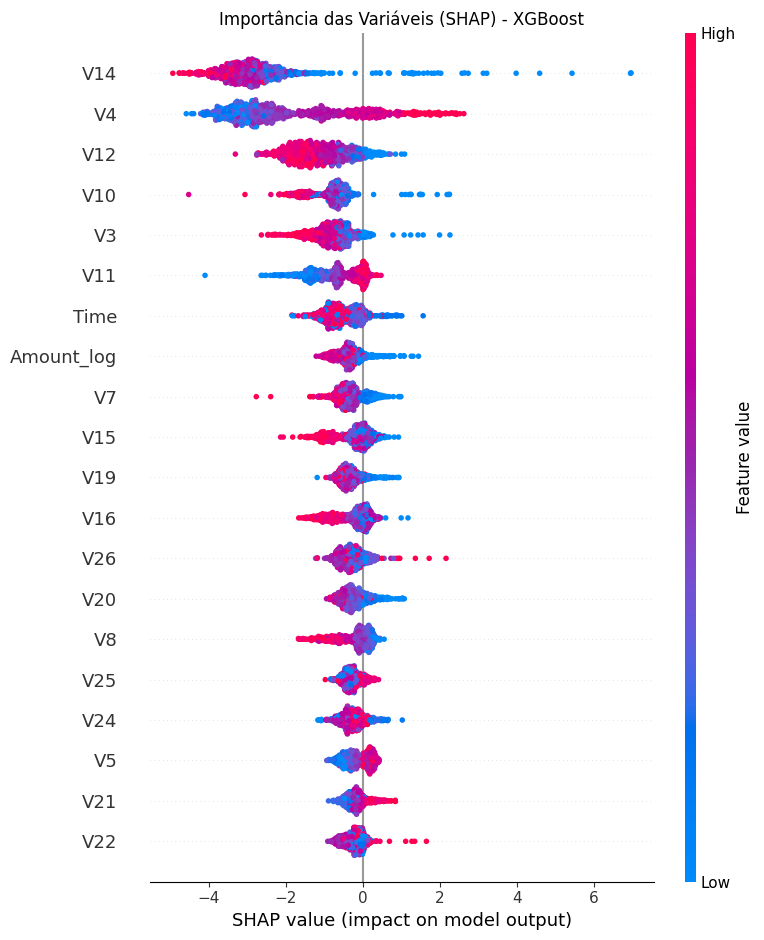

In [1]:
# ==========================================
# 1. EXPLORE: Importações e Carregamento
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_curve, auc
import shap

# DICA: Insira aqui o link do dataset passado na Aula 1
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Checando o desbalanceamento
print("Proporção de Fraudes:")
print(df['Class'].value_counts(normalize=True) * 100)

# ==========================================
# 2. PREPARE: Tratamento e Separação
# ==========================================
# Criando a variável log do Amount para reduzir o peso de valores extremos
df['Amount_log'] = np.log1p(df['Amount'])

# Padronizando Time e Amount_log
scaler = StandardScaler()
df[['Time', 'Amount_log']] = scaler.fit_transform(df[['Time', 'Amount_log']])

# Removendo a coluna Amount original
df = df.drop(columns=['Amount'])

# Separando X e y
X = df.drop('Class', axis=1)
y = df['Class']

# Divisão estratificada (MUITO IMPORTANTE para manter os 0.17% de fraude em ambos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# ==========================================
# 3. TREINE e AVALIE: Modelagem
# ==========================================
# --- Baseline: Regressão Logística com peso balanceado ---
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("--- Regressão Logística ---")
print(classification_report(y_test, y_pred_lr))

# --- Evolução: XGBoost ---
# Calculando a proporção para o hiperparâmetro scale_pos_weight
proporcao = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb = XGBClassifier(scale_pos_weight=proporcao, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("--- XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

# Ajuste de Limiar (Threshold) no XGBoost para focar no Recall
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)

# ==========================================
# 4. EXPLIQUE: SHAP Values
# ==========================================
# Usando o SHAP para entender o que o modelo considerou como fraude
explainer = shap.TreeExplainer(xgb)
# Pegamos uma amostra do X_test para o SHAP não demorar muito
shap_values = explainer.shap_values(X_test[:1000])

plt.title("Importância das Variáveis (SHAP) - XGBoost")
shap.summary_plot(shap_values, X_test[:1000])